In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import copy

from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sm import NeuralNet, LearnableActivationFunc

print(torch.__version__)

device = 'cuda'    

2.7.0+cu118


In [2]:
X, y = make_moons(n_samples=2_000, shuffle=True, noise=0.2)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

train_x = torch.from_numpy(X_train).float()
test_x = torch.from_numpy(X_test).float()
train_y = torch.from_numpy(y_train).float()
test_y = torch.from_numpy(y_test).float()

train_ds = TensorDataset(train_x, train_y)
test_ds = TensorDataset(test_x, test_y)

batch_size = 32
train_loader = DataLoader(train_ds, batch_size)
test_loader = DataLoader(test_ds, batch_size)   

In [8]:
state_dict = torch.load("/gpfs/bwfor/work/ws/hd_gy283-my_data/models/sm_vMB_n_a=200.pth", weights_only=False, map_location='cpu')
print(state_dict['args'])
model = NeuralNet(
    state_dict['args']['layer_dims'],
    state_dict['args']['x_mean'],
    state_dict['args']['x_std'],
    state_dict['args']['y_mean'],
    state_dict['args']['y_std']
)
model.load_state_dict(state_dict['model_state_dict'])

class TwoMoons(nn.Module):
    def __init__(self, model, input_dim, hidden_dim, output_dim, device):
        super().__init__()
        
        self.fc_1 = nn.Linear(input_dim, hidden_dim)
        self.fc_2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc_3 = nn.Linear(hidden_dim, hidden_dim)
        self.fc_4 = nn.Linear(hidden_dim, hidden_dim)
        self.fc_5 = nn.Linear(hidden_dim, output_dim)

        self.act_1 = LearnableActivationFunc(model, input_index=3, v_min=-1.5, v_max=1.5, data_input_ranges=None, device=device)
        self.act_2 = LearnableActivationFunc(model, input_index=3, v_min=-1.5, v_max=1.5, data_input_ranges=None, device=device)
        self.act_3 = LearnableActivationFunc(model, input_index=3, v_min=-1.5, v_max=1.5, data_input_ranges=None, device=device)
        self.act_4 = LearnableActivationFunc(model, input_index=3, v_min=-1.5, v_max=1.5, data_input_ranges=None, device=device)

    def forward(self, x):

        x = self.fc_1(x)
        x = self.act_1(x)
        x = self.fc_2(x)
        x = self.act_2(x)
        x = self.fc_3(x)
        x = self.act_3(x)
        x = self.fc_4(x)
        x = self.act_4(x)
        x = self.fc_5(x)

        return x

def forward_whole_range(model, param_list, input_idx, v_min, v_max, N):

    in_range = torch.linspace(v_min, v_max, N).unsqueeze(1)

    c_volt = torch.tensor(param_list, dtype=torch.float32).expand(N, -1)
    c_volt_l = c_volt[:, :input_idx]
    c_volt_r = c_volt[:, input_idx:]

    input_tensor = torch.cat([c_volt_l, in_range, c_volt_r], dim=1)

    model.eval()
    with torch.no_grad():
        y_out = model(input_tensor).detach().cpu().numpy()

    return y_out

{'data_dir': PosixPath('/gpfs/bwfor/work/ws/hd_gy283-my_data/data_vMB_own_pde_solver'), 'num_batches': 180, 'batch_size': 512, 'x_mean': array([-8.01042443e-05, -4.84397956e-05,  1.27591542e-04, -1.36573186e-03,
        1.29713429e-03,  9.82766649e-04, -6.81038087e-04]), 'x_std': array([0.86585553, 0.86589274, 0.86606062, 0.865617  , 0.86568139,
       0.86553458, 0.86612566]), 'y_mean': np.float64(-0.03779365664983197), 'y_std': np.float64(0.14455336756115278), 'layer_dims': [7, 128, 128, 128, 1], 'num_epochs': 500, 'lr': 0.001, 'save_name': PosixPath('/home/hd/hd_hd/hd_gy283/kmc_project/models/sm_vMB_n_a=200')}


In [12]:
#net = TwoMoons(model, 2, 20, 1, device)
#net = net.to(device)
#x = torch.linspace(-1.5, 1.5, 100).to(device)
#net.eval()
#with torch.no_grad():
#    y = net.act_1(x).detach().cpu()
#plt.plot(x.detach().cpu(), y)
#print(net.act_1.scale_cntrl())
#param_list = [-1.5, 1.5, 1.5, 0.0038004407013444313, 1.5, 1.5]
#y_t = forward_whole_range(model, param_list, 3, -1.5, 1.5, 100)
#plt.plot(x.detach().cpu(), y_t)

In [12]:
net = TwoMoons(model, 2, 20, 1, device)
net = net.to(device)    
#optimizer = torch.optim.SGD(net. parameters(), lr=1e-1, momentum=0.9)
optimizer = torch.optim.Adam(net.parameters(), lr=1e-2)
loss_fn = nn.BCEWithLogitsLoss()
epochs = 100

act_1_params = []
act_2_params = []
act_3_params = []
act_4_params = []

train_losses = []
train_accuracies = []
test_losses = []

for epoch in range(1, epochs):
    
    running_loss = 0.0
    num_correct = 0
    total_samples = 0
    
    net.train()
    for i, (x, y) in enumerate(train_loader):
        optimizer.zero_grad()
        x = x.to(device)
        y = y.unsqueeze(1).to(device)
        predictions = net(x)
        loss = loss_fn(predictions, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        with torch.no_grad():
            pred = (torch.sigmoid(predictions) >= 0.5).float()
            num_correct += (pred == y).sum().item()
            total_samples += y.size(0)
        
    if epoch % 10 == 0:
        print(f"EPOCH: {epoch}/{epochs} | Loss: {running_loss / len(train_loader.dataset)} | Accuracy: {100.0 * num_correct / total_samples}")    

    train_losses.append(running_loss / len(train_loader.dataset))
    train_accuracies.append(100.0 * num_correct / total_samples)
    
    act_1_params.append(net.act_1.scale_cntrl().detach().cpu().clone())
    act_2_params.append(net.act_2.scale_cntrl().detach().cpu().clone())
    act_3_params.append(net.act_3.scale_cntrl().detach().cpu().clone())
    act_4_params.append(net.act_4.scale_cntrl().detach().cpu().clone())
    
net.eval()
with torch.no_grad():
    running_loss = 0.0
    num_correct = 0
    total_samples = 0
    for (x, y) in test_loader:
        x = x.to(device)
        y = y.unsqueeze(1).to(device)

        predictions = net(x)
        loss = loss_fn(predictions, y)
        running_loss += loss.item()

        pred = (torch.sigmoid(predictions) >= 0.5).float()
        num_correct += (pred == y).sum().item()
        total_samples += y.size(0)
    print(f"Test Loss: {running_loss / len(test_loader.dataset)} | Accuracy: {100.0 * num_correct / total_samples}")

    test_losses.append(running_loss / len(test_loader.dataset))

EPOCH: 10/100 | Loss: 0.0037237078609565896 | Accuracy: 95.66666666666667
EPOCH: 20/100 | Loss: 0.004110551413148642 | Accuracy: 95.66666666666667
EPOCH: 30/100 | Loss: 0.0033061868958175183 | Accuracy: 95.73333333333333
EPOCH: 40/100 | Loss: 0.003266425419598818 | Accuracy: 95.46666666666667
EPOCH: 50/100 | Loss: 0.0032644275029500326 | Accuracy: 95.8
EPOCH: 60/100 | Loss: 0.003338510040193796 | Accuracy: 95.46666666666667
EPOCH: 70/100 | Loss: 0.003294655439754327 | Accuracy: 95.46666666666667
EPOCH: 80/100 | Loss: 0.0032063882586856685 | Accuracy: 95.93333333333334
EPOCH: 90/100 | Loss: 0.0030853806796173255 | Accuracy: 95.6
Test Loss: 0.0037236074525862934 | Accuracy: 96.2


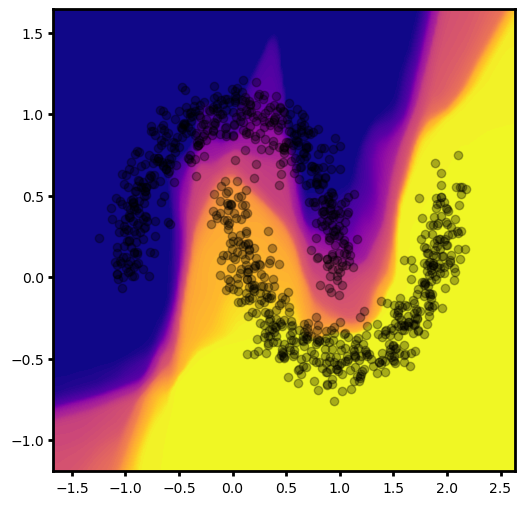

In [10]:
pad = 0.2

dataset = make_moons(1500, noise=0.2)

x_min = dataset[0][:,0].min() - pad
x_max = dataset[0][:,0].max() + pad

y_min = dataset[0][:,1].min() - pad
y_max = dataset[0][:,1].max() + pad
N = 200
X, Y = np.meshgrid(np.linspace(x_min, x_max, N), np.linspace(y_min, y_max, N))
X = X.reshape(-1, 1)
Y = Y.reshape(-1, 1)

input_tensor = torch.cat([torch.from_numpy(X).float(), torch.from_numpy(Y).float()], dim=1)
input_tensor = input_tensor.to(device)

with torch.no_grad():
    out = net(input_tensor).detach().cpu().numpy()
out = out.reshape(N, N)

X = X.reshape(200, 200)
Y = Y.reshape(200, 200)

fig, ax = plt.subplots(figsize=(6,6))
ax.spines[:].set_linewidth(2)
ax.tick_params(width=2)
ax.set_box_aspect(1)
cntrf = ax.contourf(X, Y, out, levels=100, cmap='plasma')

sample_n, _ = make_moons(1_000, noise=0.1)
ax.scatter(*sample_n.T, c='k', alpha=0.3)

#plt.colorbar(cntrf)

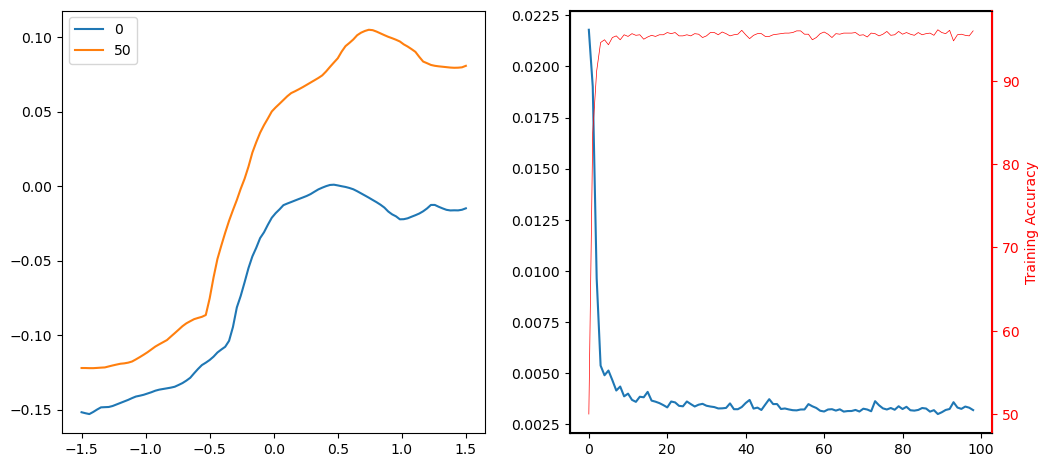

In [11]:
model.eval()
input_idx = 3
N = 100
x = torch.linspace(-1.5, 1.5, N).unsqueeze(1)
ncols = 2

fig, axs = plt.subplots(ncols=ncols, figsize=(6*ncols, 6))

for ax in axs:
    ax.set_box_aspect(1)
    

for i in range(0, len(act_1_params), 50):
    with torch.no_grad():
        c_volt = act_2_params[i].expand(N, -1)
        c_volt_l = c_volt[:, :input_idx]
        c_volt_r = c_volt[:, input_idx:]
        input_tensor = torch.cat([c_volt_l, x, c_volt_r], dim=1)
        y = model(input_tensor).detach().cpu()
        axs[0].plot(x, y, label=f'{i}')

param_list = [-1.5, 1.5, 1.5, 0.0038004407013444313, 1.5, 1.5]
y = forward_whole_range(model, param_list, 3, -1.5, 1.5, N)
#axs[0].plot(x, y)

axs[0].legend()

axs[1].plot(train_losses)
axs[1].spines[['left', 'top', 'bottom']].set_linewidth(1.5)

axs1_2 = axs[1].twinx()
axs1_2.set_box_aspect(1)
color = 'r'

axs1_2.plot(train_accuracies, c=color, lw=0.5)
axs1_2.tick_params(axis='y', colors=color, labelcolor=color)
axs1_2.set_ylabel('Training Accuracy', c=color)
axs1_2.spines['right'].set_color(color)
axs1_2.spines['right'].set_linewidth(1.5)

#axs[1].set_yscale('symlog', linthresh=1e-8)